In [91]:
%uv pip install pyro-ppl
%uv pip install arviz

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 11ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 14ms
Note: you may need to restart the kernel to use updated packages.


In [92]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import torch
import pyro
import pyro.distributions as pdist
import torch.distributions as tdist
import arviz as az

# Part 1

In [93]:
data = np.genfromtxt('/mnt/pml/data_part_B.csv', delimiter=',')
X_noisy=data[:, 0]
y=data[:, 1]
delta=data[:, 2]
X_clean = X_noisy - delta
noise_x = 0.01
noise_y = 0.0025

In [94]:
def negLogLikelihood(params, kernel, S, y):
    noise_y = params[0]
    eta = params[1:]    
    K_eta = kernel(S, eta)
    l = len(S)
    Sigma = noise_y * np.eye(l) + K_eta


    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        print("error")
        return None

    sol = np.linalg.solve(Sigma, y)
    quad_term = 0.5 * y.T @ sol


    log_likelihood = -quad_term - 0.5 * logdet - (l/2) * np.log(2 * np.pi)
    
    return -log_likelihood 

def conditional(Xp, X, y, noise_var, eta, kernel):
    X_concat = np.concat([X, Xp])
    K_concat = kernel(X_concat, eta)
    K_XX = K_concat[:len(X), :len(X)] + noise_var*np.eye(len(X))
    K_XXp = K_concat[:len(X), len(X):]
    K_XpX = K_concat[len(X):, :len(X)]
    K_XpXp = K_concat[len(X):, len(X):]
    K_XX_inv = np.linalg.inv(K_XX)
    
    mustar = K_XXp.T@K_XX_inv@y
    Sigmastar = K_XpXp - K_XXp.T@K_XX_inv@K_XXp

    return mustar, Sigmastar # return mean and covariance matrix


In [95]:
def optimize_params(ranges, kernel, Ngrid, S, y):
    opt_params = opt.brute(lambda params: negLogLikelihood(params, kernel, S, y), ranges, Ns=Ngrid, finish=None)
    noise_var = opt_params[0]
    eta = opt_params[1:]
    return noise_var, eta

In [96]:
def K(S, eta):
    #S=[x_0,x_1,...,x_n]
    gamma = eta[0]
    K_RBF=np.exp(-gamma * (S.reshape(-1,1)-S)**2)
    return K_RBF

In [97]:
#a) 
ranges = ((1.e-3,10), (1.e-3,20))
Ngrid = 20
noise_var_a, eta_a = optimize_params(ranges, K, Ngrid, X_noisy, y)

print("optimal params:")
print('sigma_y:', noise_var_a)
print(f'gamma: {eta_a[0]:.3f}') 


optimal params:
sigma_y: 0.5272631578947369
gamma: 1.054


In [98]:
#b) 
fixed_noise_y = 0.0025
ranges = ((fixed_noise_y,fixed_noise_y), (1.e-3,20))
Ngrid = 20
noise_var_b, eta_b = optimize_params(ranges, K, Ngrid, X_noisy, y)
print("optimal params:")
print('sigma_y:', noise_var_b)
print(f'gamma: {eta_b[0]:.3f}') 


optimal params:
sigma_y: 0.0025
gamma: 20.000


In [99]:
#c) 
fixed_noise_y = 0.0025
ranges = ((fixed_noise_y,fixed_noise_y), (1.e-3,20))
Ngrid = 20
noise_var_c, eta_c = optimize_params(ranges, K, Ngrid, X_clean, y)

print("optimal params:")
print('sigma_y:', noise_var_c)
print(f'gamma: {eta_c[0]:.3f}') 

optimal params:
sigma_y: 0.0025
gamma: 4.211


In [100]:
X_grid = np.linspace(-1, 1, 100)
mu_a, Sigma_a = conditional(X_grid, X_noisy, y, noise_var_a, eta_a, K)
mu_b, Sigma_b = conditional(X_grid, X_noisy, y, noise_var_b, eta_b, K)
mu_c, Sigma_c = conditional(X_grid, X_clean, y, noise_var_c, eta_c, K)

In [101]:
def f_ground_truth(x):
    return -x**2 +2/(1+ np.exp(-10*x))

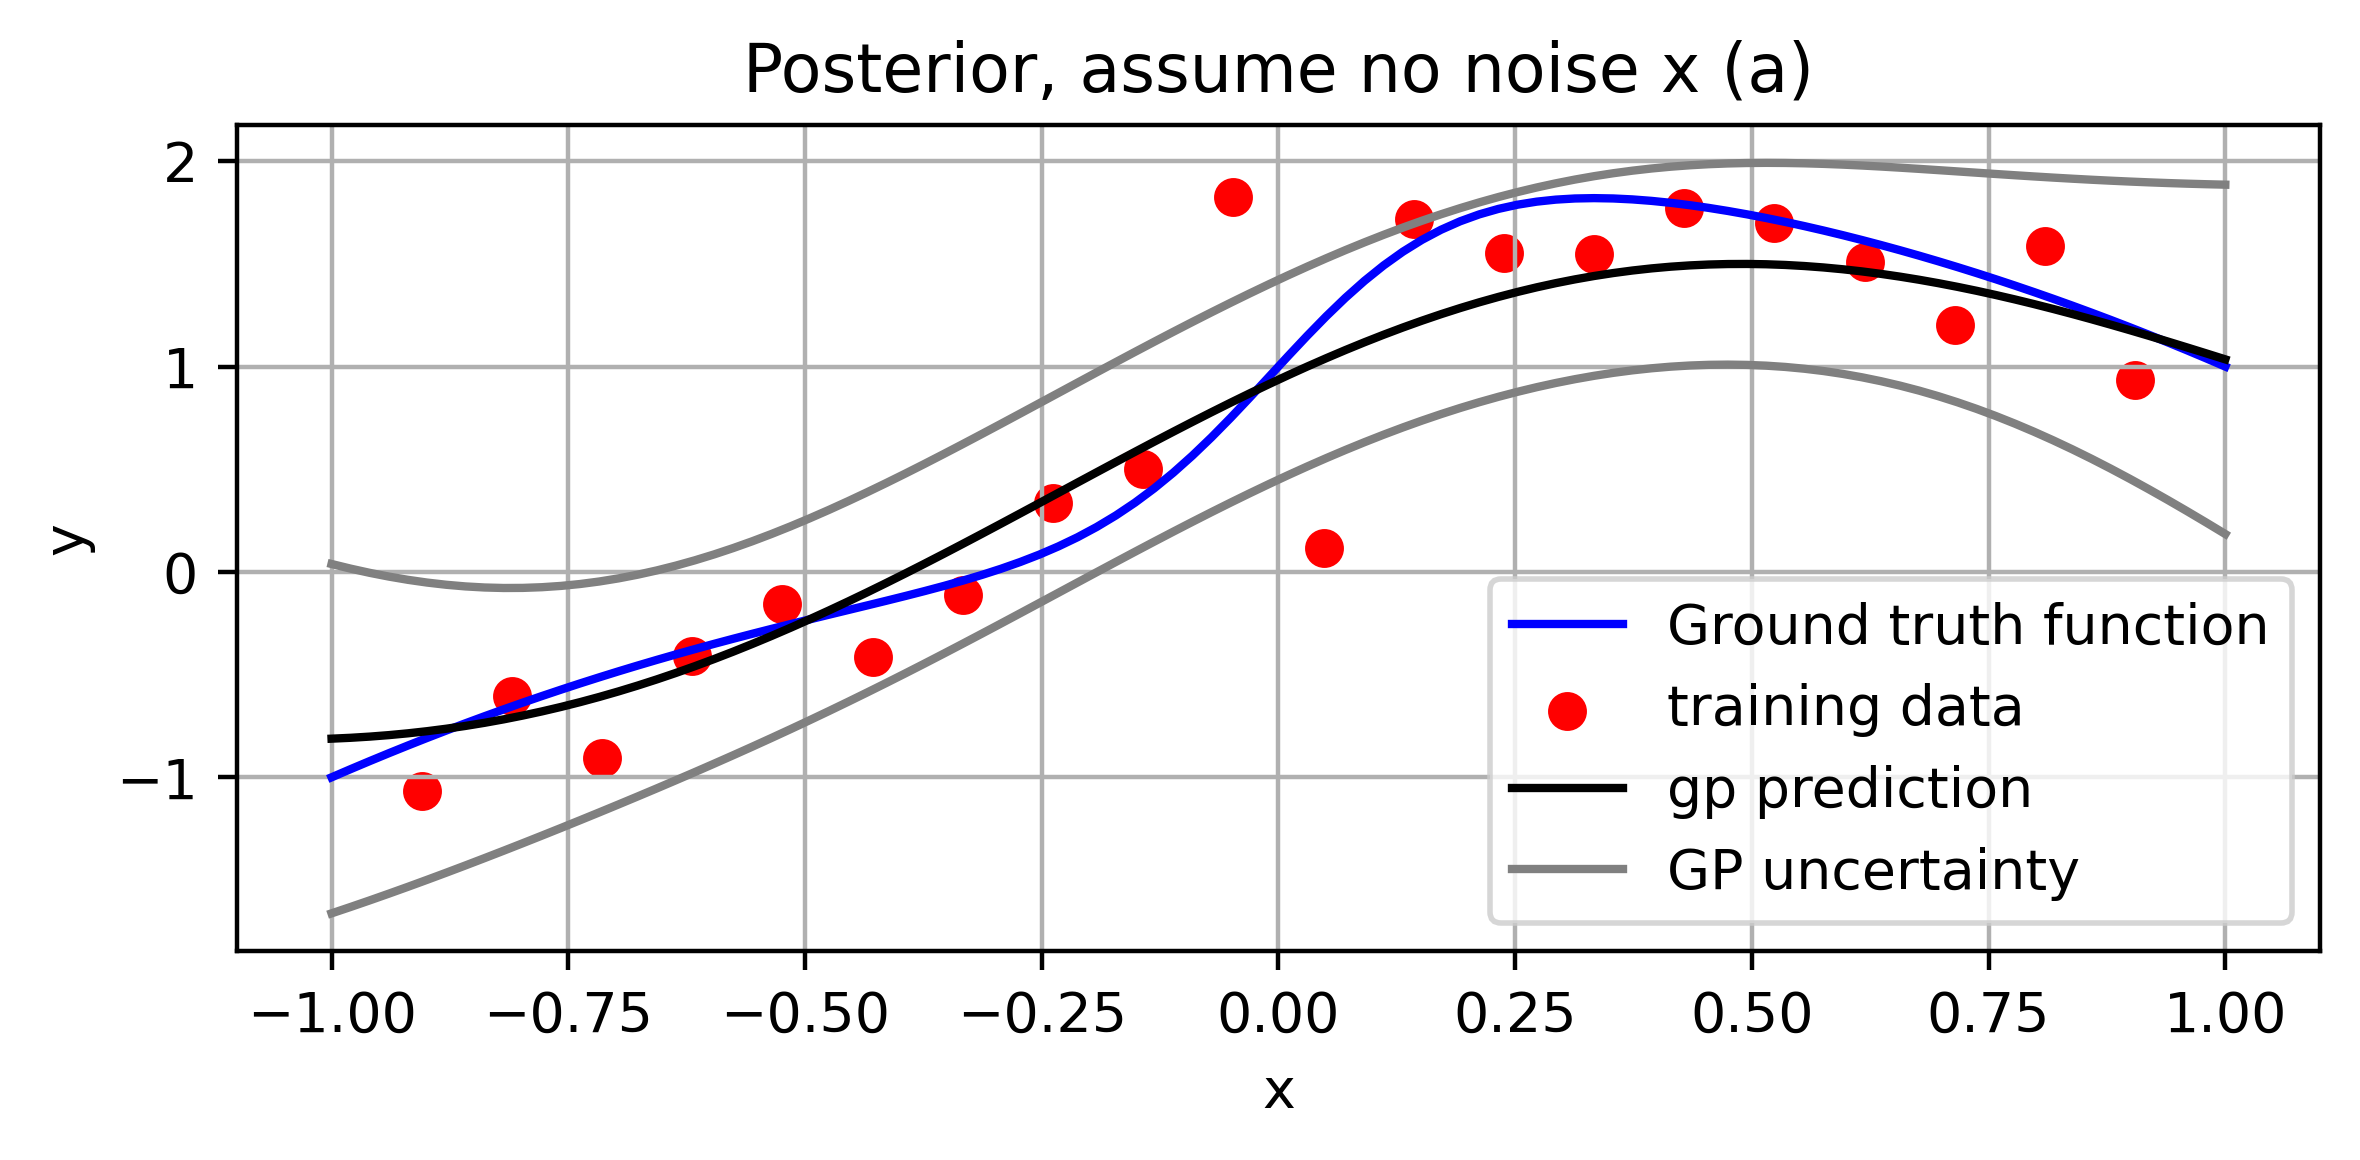

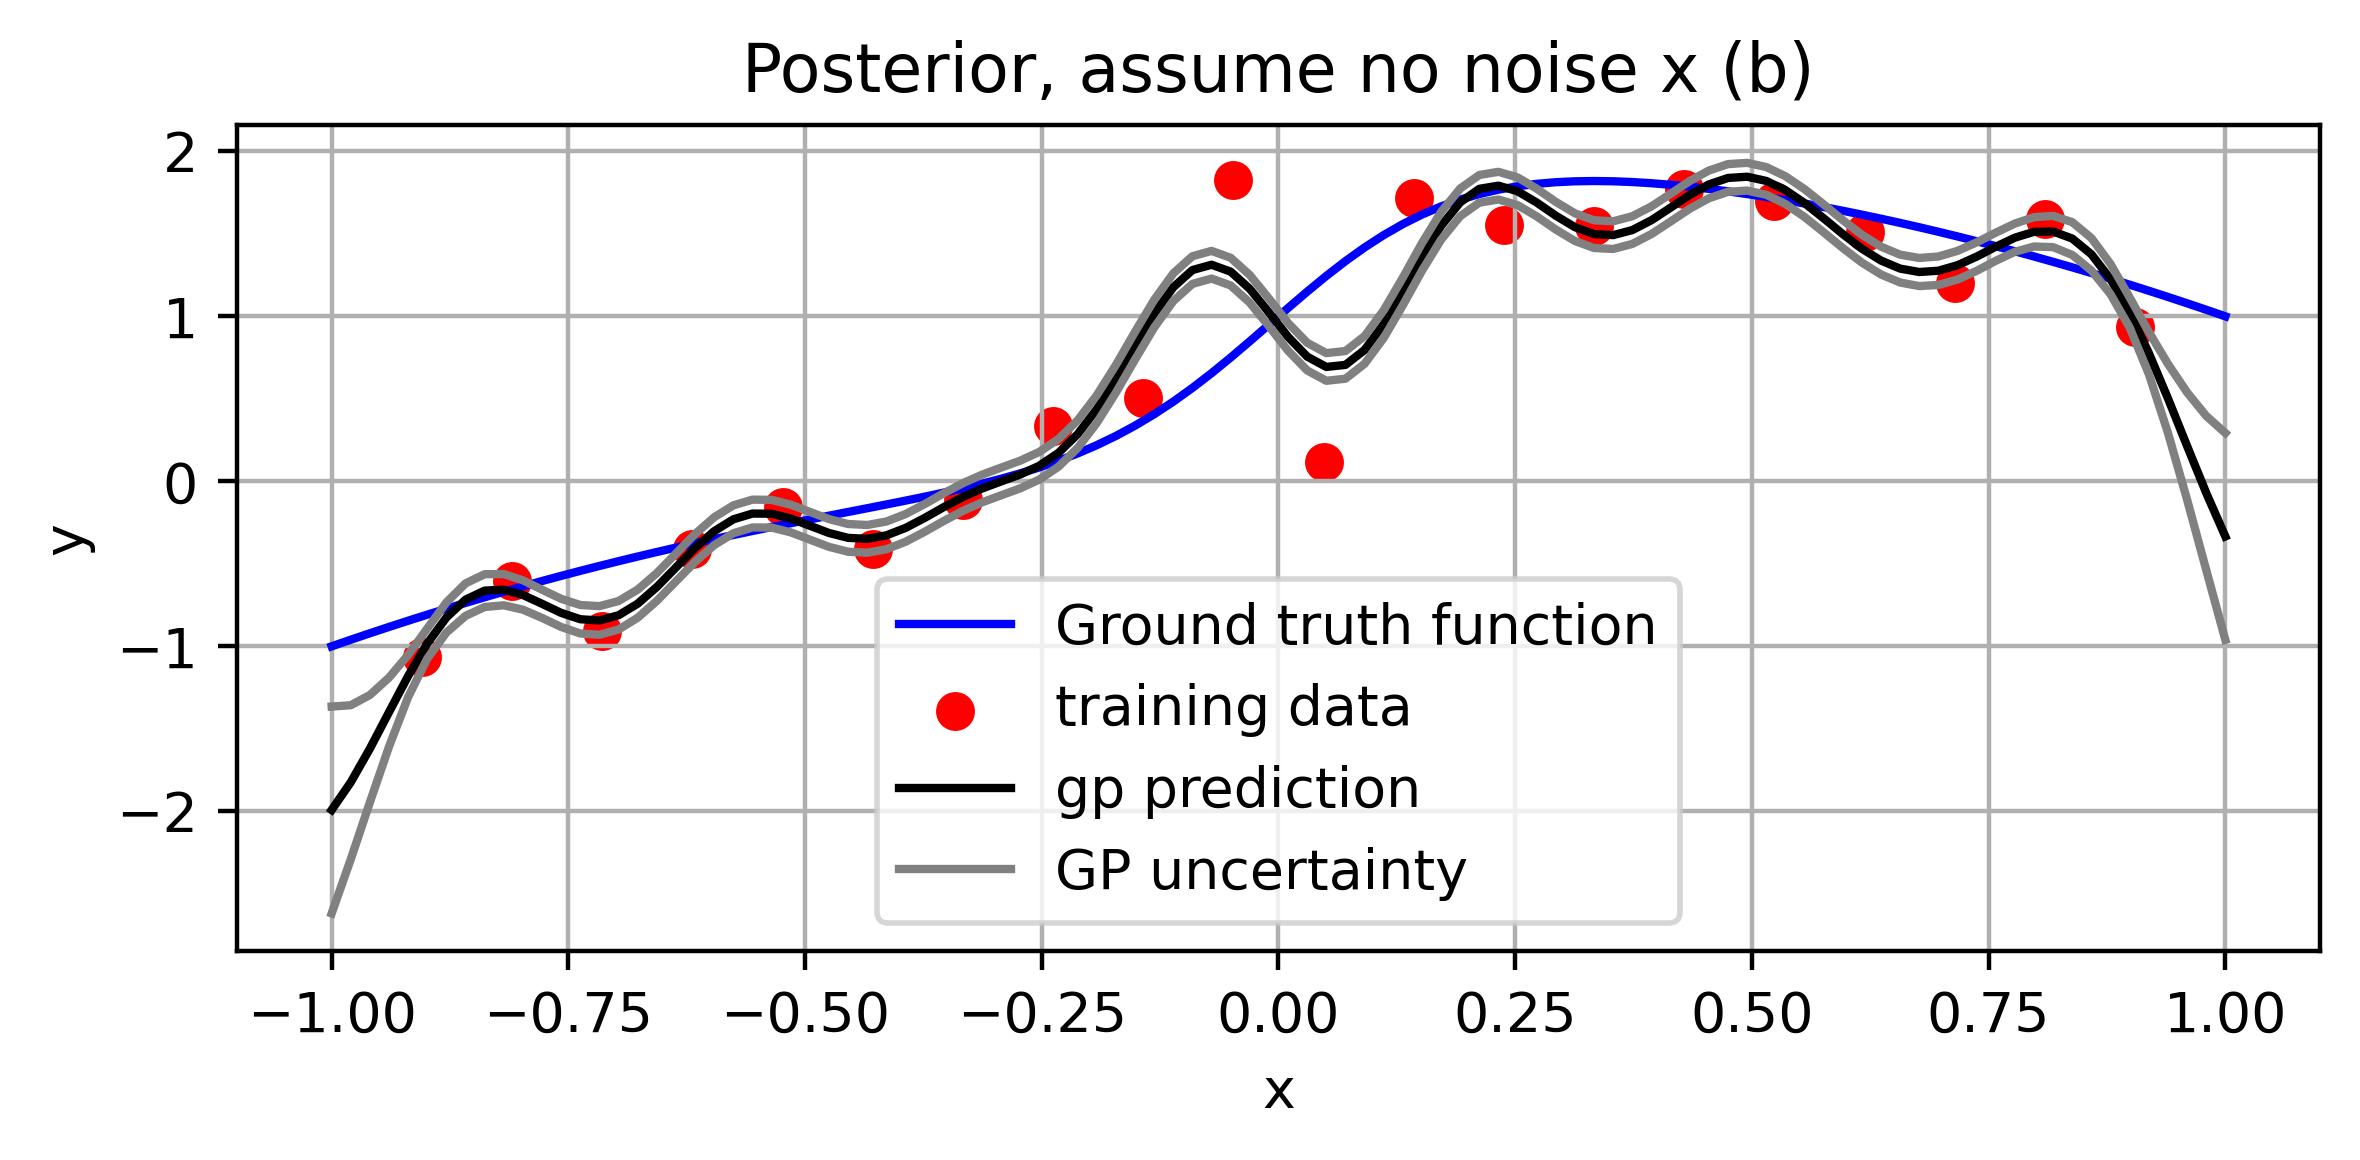

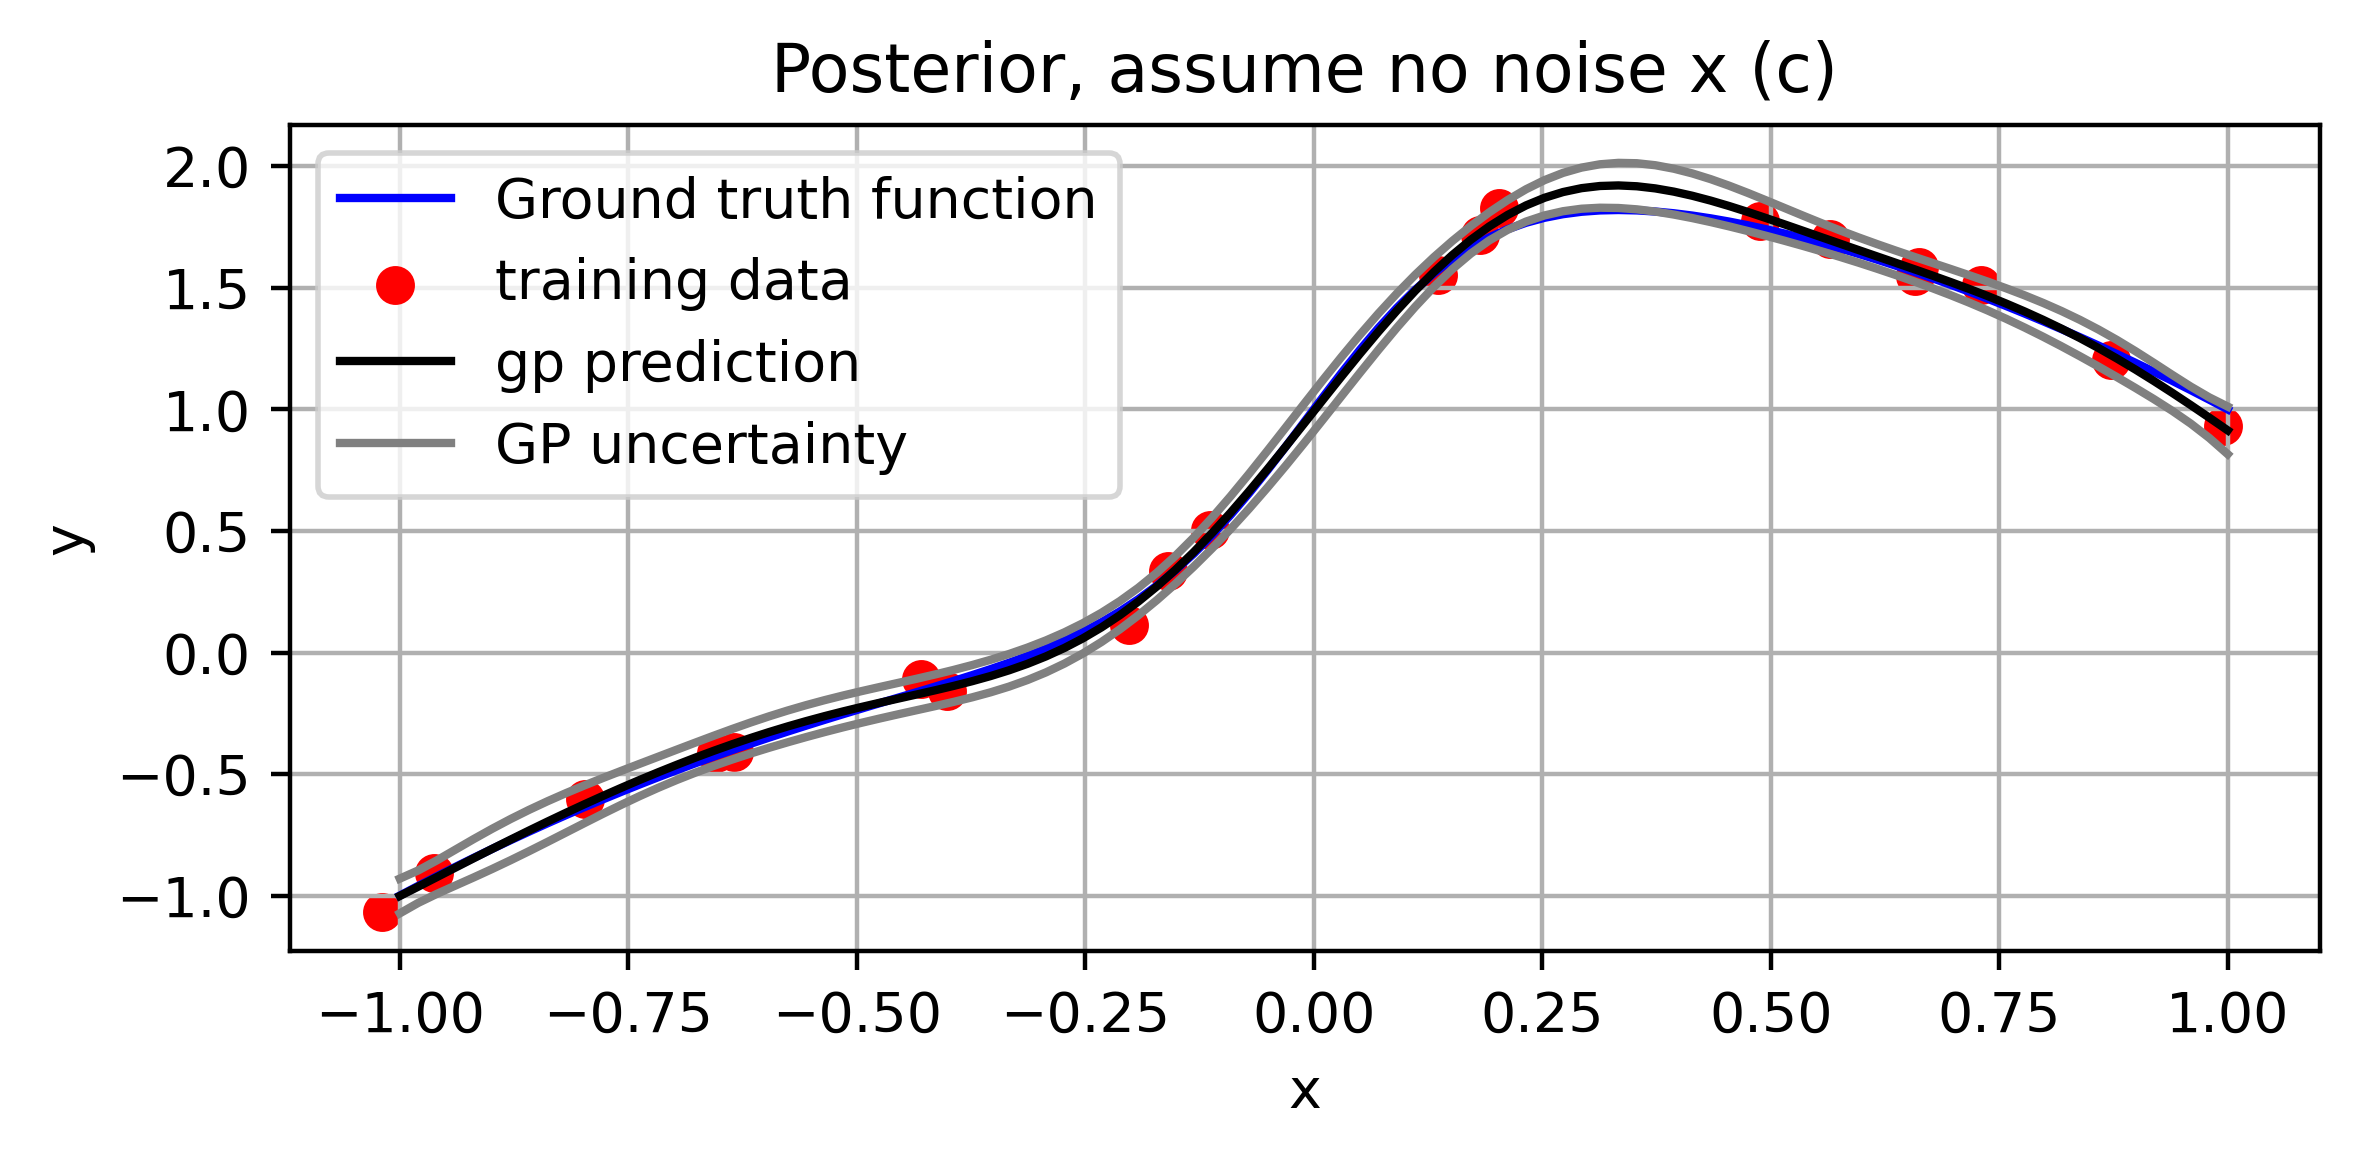

In [102]:
X_grid = np.linspace(-1, 1, 100)
def plot_posterior_of_model(mu, Sigma, X_grid, X,y, part):
    ## X_grid: the grid where prediction makes
    plt.figure(dpi=400,figsize=(6,3))
    plt.plot(X_grid, f_ground_truth(X_grid), color="blue", label="Ground truth function")
    plt.scatter(X, y, color='red', label='training data')
    var=np.diag(Sigma)
    plt.plot(X_grid, mu, color='black', label='gp prediction')
    plt.plot(X_grid, mu + 1.96*var**0.5, color='grey', label='GP uncertainty')
    plt.plot(X_grid, mu - 1.96*var**0.5, color='grey')
    plt.title(f'Posterior, assume no noise x ({part})')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('on')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

plot_posterior_of_model(mu_a, Sigma_a, X_grid, X_noisy, y, "a")
plot_posterior_of_model(mu_b, Sigma_b, X_grid, X_noisy, y, "b")
plot_posterior_of_model(mu_c, Sigma_c, X_grid, X_clean, y, "c")

# Part 2


In [103]:
def K(S, eta):
    #S=[x_0,x_1,...,x_n]
    gamma = eta[0]
    K_RBF=np.exp(-gamma * (S.reshape(-1,1)-S)**2)
    return K_RBF
def K1(S, eta):
    gamma = eta[0]
    return -2*gamma*(S.reshape(-1,1)-S)*K(S, eta)
    
def K2(S, eta):
    gamma = eta[0]
    return 2*gamma*(1- 2*gamma*(S.reshape(-1,1)-S)**2)*K(S, eta)


def BIG_K(S, eta):
    up = np.hstack((K(S,eta),K1(S,eta).T))
    down = np.hstack((K1(S,eta),K2(S,eta)))
    return np.vstack((up, down))

In [104]:
# compute joint prior sample
S = np.linspace(-1, 1, 100)
samples = np.random.multivariate_normal(np.zeros(len(S)*2), BIG_K(S, eta_a))
f = samples[0:len(S)]
fp = samples[len(S):]
estimated_derivs = (f[2:100] - f[0:98])/(S[2:100] - S[0:98])
derivs_diff = estimated_derivs - fp[1:99]
print('the absolute mean difference is:',abs(derivs_diff).mean())

the absolute mean difference is: 0.0005109444119833421


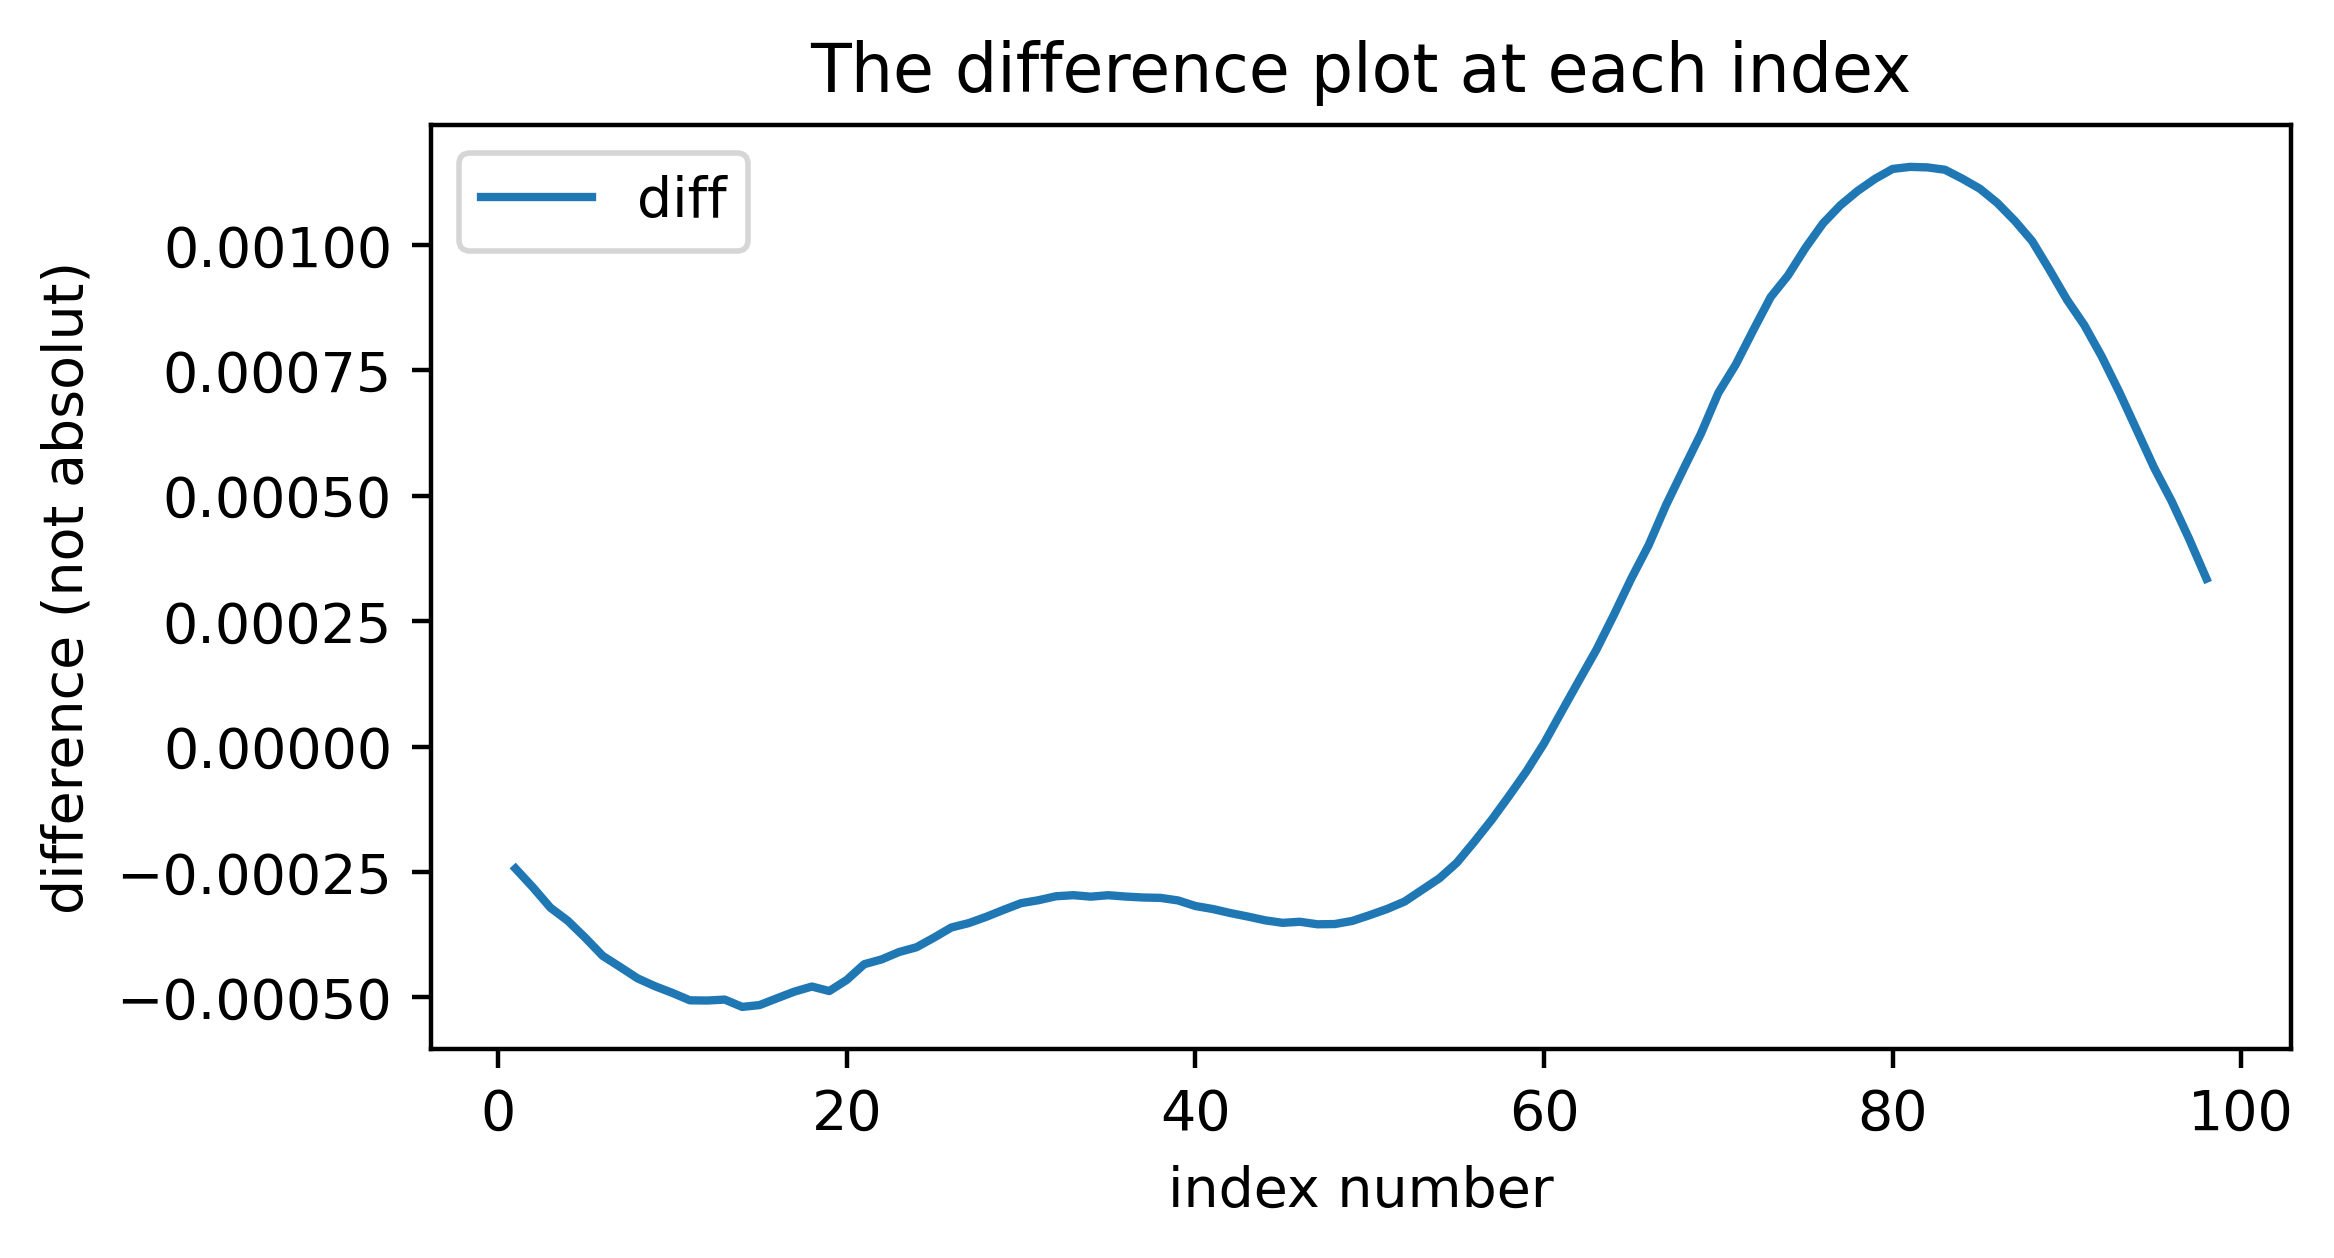

In [105]:
plt.figure(dpi=400,figsize=(6,3))
plt.plot(np.arange(1,99), derivs_diff,label='diff')
plt.title('The difference plot at each index')
plt.xlabel("index number")
plt.ylabel("difference (not absolut)")
plt.legend()
plt.show()

In [106]:
def Sigma_noisy_X(S, eta, noise_y, delta):
    D = np.diag(delta)
    l = len(S)
    I = np.eye(l)
    Q = np.hstack((I,-D))  # Treat the calc as a linear transformation of big K
    K_NEW = Q@BIG_K(S, eta)@Q.T
    return K_NEW
    

def negLogLikelihood(params, S, y, delta):
    noise_y = params[0]
    eta = params[1:]    
    l = len(S) 
    Sigma = noise_y * np.eye(l) + Sigma_noisy_X(S, eta, noise_y, delta)


    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        print("error")
        return None

    sol = np.linalg.solve(Sigma, y)
    quad_term = 0.5 * y.T @ sol


    log_likelihood = -quad_term - 0.5 * logdet - (l/2) * np.log(2 * np.pi)
    
    return -log_likelihood 
    

In [107]:
def optimize_params(ranges, Ngrid, S, y, delta):
    opt_params = opt.brute(lambda params: negLogLikelihood(params, S, y, delta), ranges, Ns=Ngrid, finish=None)
    noise_var = opt_params[0]
    eta = opt_params[1:]
    return noise_var, eta

In [108]:
ranges = ((1e-3, 20), (1e-3, 20))
Ngrid = 20
noise_var, eta = optimize_params(ranges, Ngrid, X_noisy, y, delta)
print("optimal params:")
print('sigma_y:', noise_var)
print(f'gamma: {eta[0]:.3f}') 

optimal params:
sigma_y: 0.001
gamma: 6.316


In [109]:
def conditional(Xp, X, y, noise_var, eta, kernel, delta):
    X_concat = np.concat([X, Xp])
    predicted_delta=np.zeros_like(Xp)
    delta_concat = np.append(delta, predicted_delta)
    K_concat = Sigma_noisy_X(X_concat, eta, noise_var, delta_concat)
    K_XX = K_concat[:len(X), :len(X)] + np.eye(len(X)) * noise_var
    K_XXp = K_concat[:len(X), len(X):]
    K_XpX = K_concat[len(X):, :len(X)]
    K_XpXp = K_concat[len(X):, len(X):]

    # K_XpXp = Sigma_noisy_X(Xp, eta, noise_var, predicted_delta) - np.eye(len(Xp))*noise_y
    K_XX_inv = np.linalg.inv(K_XX)
    
    mustar = K_XXp.T@K_XX_inv@y
    Sigmastar = K_XpXp - K_XXp.T@K_XX_inv@K_XXp

    return mustar, Sigmastar # return mean and covariance matrix 

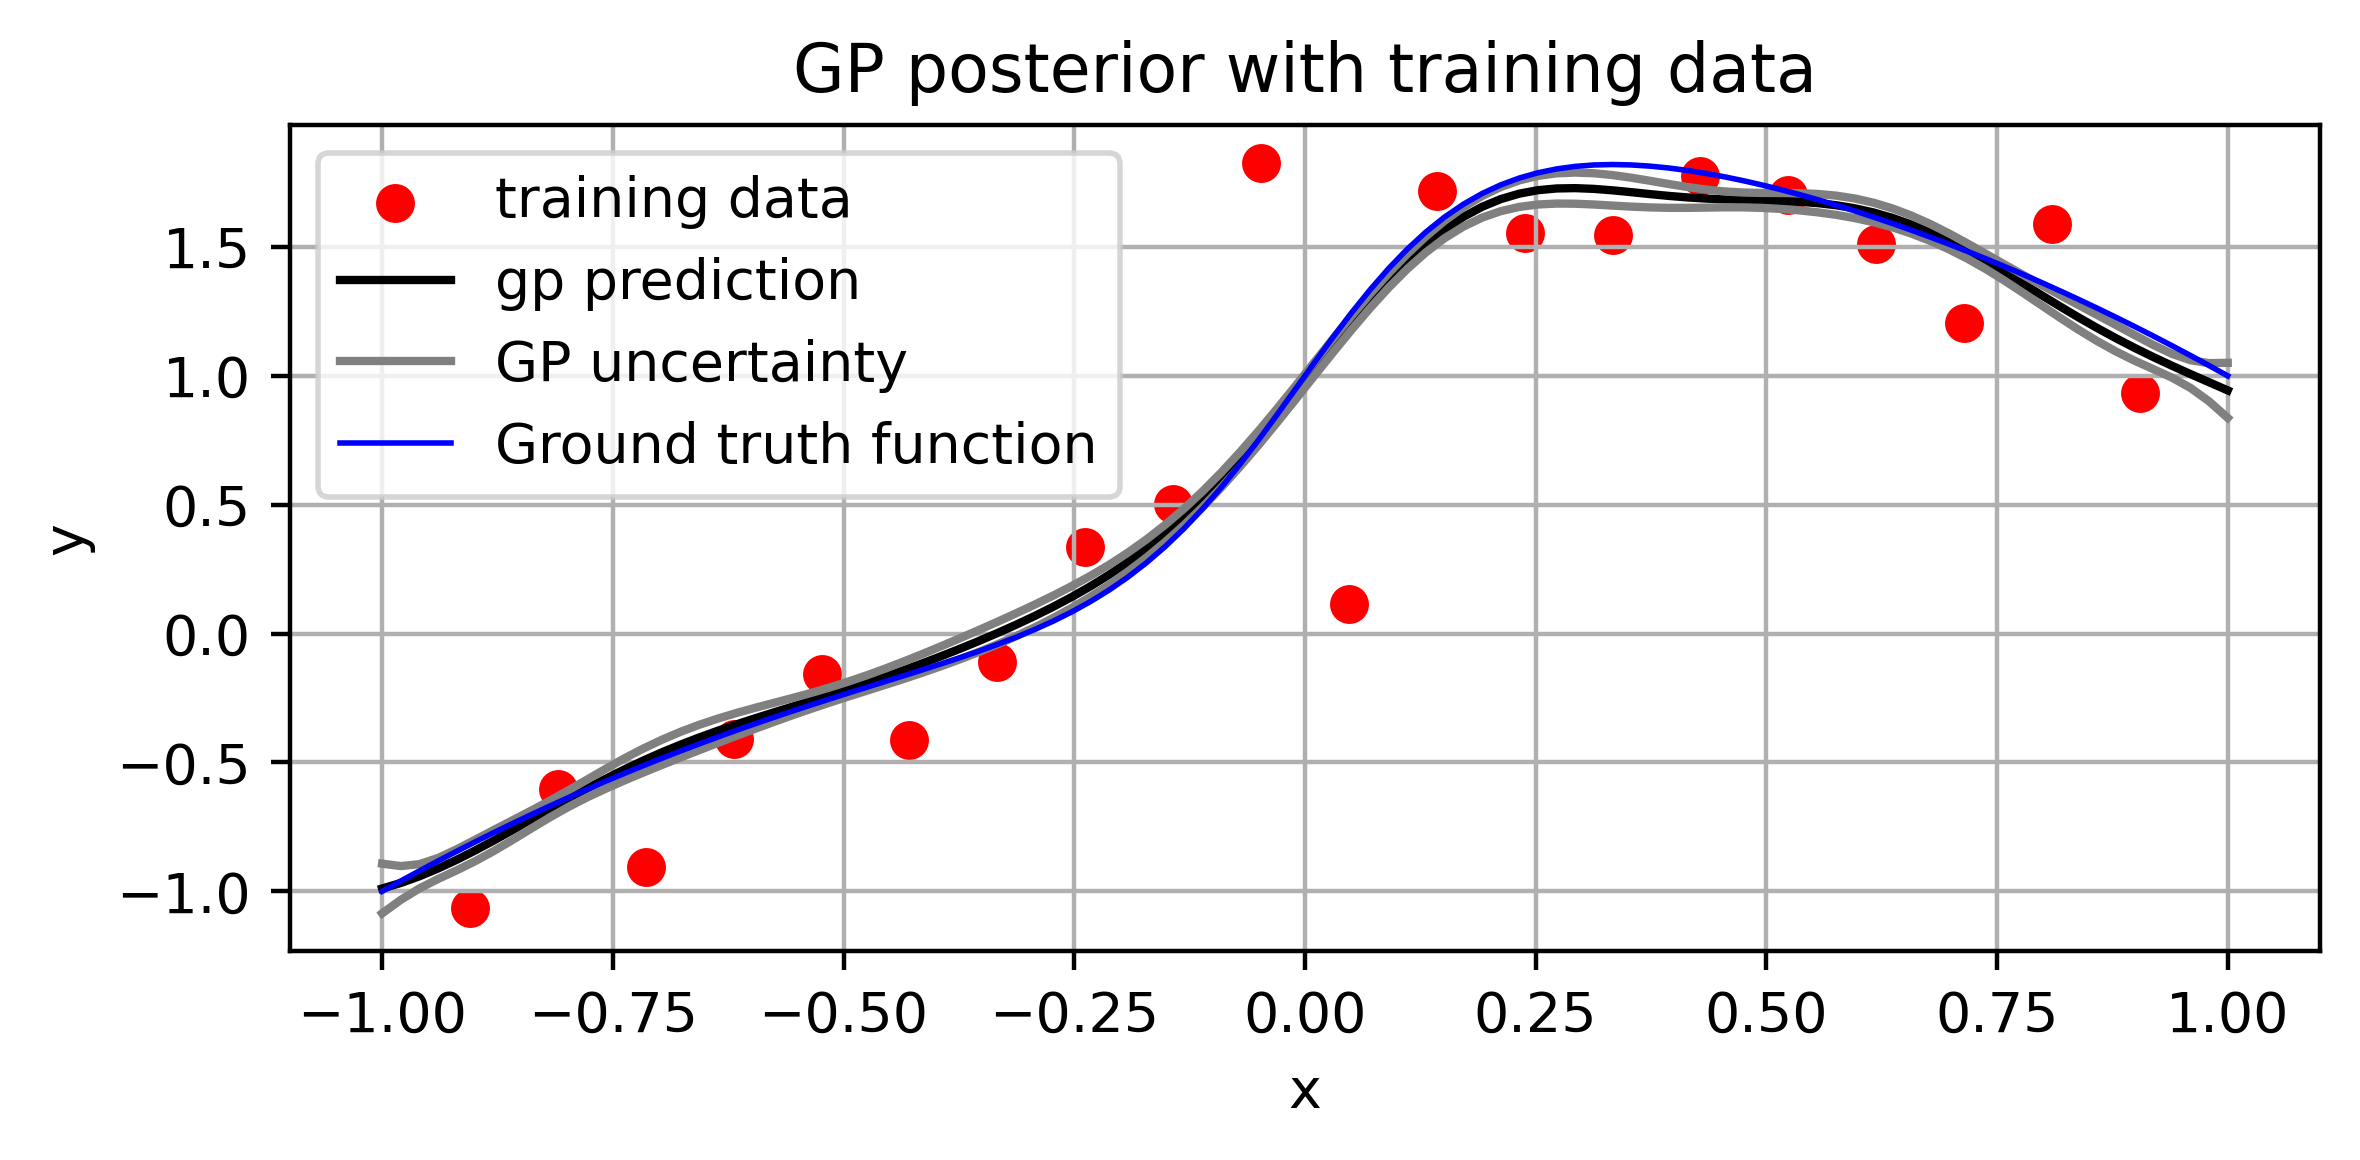

In [110]:
X_grid = np.linspace(-1, 1, 100)
mu, Sigma = conditional(X_grid, X_noisy, y, noise_var, eta, K, delta)
## X_grid: the grid where prediction makes, and thus in this case the delta on the prediction should be 0
plt.figure(dpi=400,figsize=(6,3))

plt.scatter(X_noisy, y, color='red', label='training data')
var=np.diag(Sigma)
plt.plot(X_grid, mu, color='black', label='gp prediction')
plt.plot(X_grid, mu + 1.96*var**0.5, color='grey', label='GP uncertainty')
plt.plot(X_grid, mu - 1.96*var**0.5, color='grey')
plt.plot(X_grid, f_ground_truth(X_grid), color="blue", lw=1, label="Ground truth function")
plt.title('GP posterior with training data')
plt.xlabel("x")
plt.ylabel("y")
plt.axis('on')
plt.grid(True)
plt.legend()
plt.tight_layout()

### nuts


In [111]:
def K_t(S, eta):
    #S=[x_0,x_1,...,x_n]
    gamma = eta[0]
    K_RBF=torch.exp(-gamma * (S.reshape(-1,1)-S)**2)
    return K_RBF
def K1_t(S, eta):
    gamma = eta[0]
    return -2*gamma*(S.reshape(-1,1)-S)*K_t(S, eta)
    
def K2_t(S, eta):
    gamma = eta[0]
    return 2*gamma*(1- 2*gamma*(S.reshape(-1,1)-S)**2)*K_t(S, eta)

def BIG_K_t(S, eta):
    up = torch.hstack((K_t(S,eta),K1_t(S,eta).T))
    down = torch.hstack((K1_t(S,eta),K2_t(S,eta)))
    return torch.vstack((up, down))

In [112]:
def Sigma_noisy_X_t(S, eta, noise_y, delta):
    D = torch.diag(delta)
    l = S.shape[0]
    I = torch.eye(l)
    Q = torch.hstack((I,-D))  # Treat the calc as a linear transformation of big K
    K_NEW = Q@BIG_K_t(S, eta)@Q.T
    return K_NEW
    

def negLogLikelihood_t(params, S, y, delta):
    noise_y = params[0]
    eta = params[1:]    
    l = S.shape[0]
    Sigma = noise_y * torch.eye(l) + Sigma_noisy_X_t(S, eta, noise_y, delta)


    sign, logdet = torch.linalg.slogdet(Sigma)
    if sign <= 0:
        print("error")
        return None

    sol = torch.linalg.solve(Sigma, y)
    quad_term = 0.5 * y.T @ sol


    log_likelihood = -quad_term - 0.5 * logdet - (l/2) * np.log(2 * np.pi)
    
    return -log_likelihood 
    

In [113]:
# Taken from exercises and modified
noise_var_t = torch.tensor(noise_var, dtype=torch.float32)
noise_x_t = torch.tensor(noise_x, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)
eta_t = torch.tensor(eta, dtype=torch.float32)
X_noisy_t = torch.tensor(X_noisy, dtype=torch.float32)

In [114]:
from torch.distributions import constraints

class MyDensity(pdist.TorchDistribution):
    support = constraints.interval(-3,3) # TODO add constraints for support
    # Constraint for the starting value used in the sampling
    # (should be within integration interval) 
    arg_constraints = {"start": support}

    def __init__(self, length = 20):
        

        
      self.start = torch.zeros(length)
      super(pdist.TorchDistribution, self).__init__()

    def sample(self, sample_shape=torch.Size()):
        return self.start

    def log_prob(self, delta):
        params = [noise_var_t, eta_t]
        S = X_noisy_t
        
        loglikelihood = -negLogLikelihood_t(params, S, y_t, delta)
        logprior =pdist.MultivariateNormal(torch.zeros_like(S), noise_x*torch.eye(len(S))).log_prob(delta)
        return loglikelihood + logprior


In [115]:
# Specify the model, which in our case is just our MyDensity distribution

def model():
    delta = pyro.sample("delta", MyDensity())
    return delta

In [116]:
def model(X, y, noise_y, noise_x, eta, kernel):
    l=X.shape[0]
    deltas=pyro.sample('delta', pdist.Normal(0, noise_x).expand([l]))
    Sigma = Sigma_noisy_X_t(X, eta, noise_y, deltas)
    pyro.sample('y', pdist.MultivariateNormal(torch.zeros(l), Sigma+noise_y * torch.eye(l)),obs=y)

In [129]:
# Run HMC / NUTS
nuts_kernel = pyro.infer.NUTS(model, jit_compile=True)
mcmc = pyro.infer.MCMC(nuts_kernel, num_samples=2000, num_chains = 3, warmup_steps = 500)
mcmc.run(X_noisy_t, y_t, noise_var_t, noise_x_t, eta_t, K_t)
samples = mcmc.get_samples(group_by_chain=True)["delta"]

Warmup [1]:   0%|          | 0/2500 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/2500 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/2500 [00:00, ?it/s]

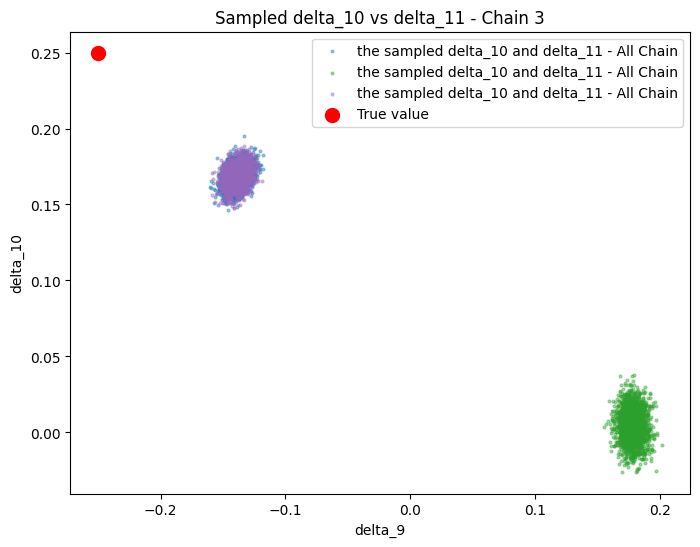

In [130]:
import numpy as np
idx_1,idx_2=9,10
plt.figure(figsize=(8, 6))
for i in range(3):
    plt.scatter(samples[i,:,idx_1],samples[i,:,idx_2],s=4, alpha=0.4,label='the sampled delta_10 and delta_11 - All Chain')
    plt.scatter(samples[i,:,idx_1] + 0.0001,samples[i,:,idx_2] - 0.0001,s=4,alpha=0.000) # shadow effect
plt.scatter(delta[idx_1],delta[idx_2],color='red', s=100, label='True value')
plt.xlabel(f'delta_{idx_1}')
plt.ylabel(f'delta_{idx_2}')
plt.title(f'Sampled delta_10 vs delta_11 - Chain {i+1}')
plt.legend()
plt.show()

In [131]:
nuts_inference = az.from_pyro(mcmc)
nuts_summary = az.summary(nuts_inference, var_names=['delta'])
print(nuts_summary)

/usr/local/lib/python3.12/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
delta[0]  -0.000  0.010  -0.018    0.019      0.000    0.000    9146.0   
delta[1]  -0.043  0.011  -0.062   -0.023      0.004    0.000       8.0   
delta[2]   0.047  0.013   0.023    0.070      0.005    0.001       6.0   
delta[3]  -0.003  0.011  -0.024    0.018      0.003    0.000      14.0   
delta[4]  -0.005  0.023  -0.038    0.038      0.012    0.004       5.0   
delta[5]   0.021  0.013  -0.004    0.045      0.005    0.001       7.0   
delta[6]   0.013  0.013  -0.009    0.036      0.006    0.001       5.0   
delta[7]  -0.002  0.045  -0.050    0.071      0.026    0.009       5.0   
delta[8]  -0.041  0.017  -0.074   -0.017      0.009    0.003       5.0   
delta[9]  -0.033  0.149  -0.150    0.186      0.086    0.030       5.0   
delta[10]  0.114  0.078  -0.007    0.181      0.045    0.016       5.0   
delta[11] -0.050  0.071  -0.158    0.015      0.041    0.014       5.0   
delta[12] -0.020  0.010  -0.035    0.0

Text(0.5, 0, 'Delta')

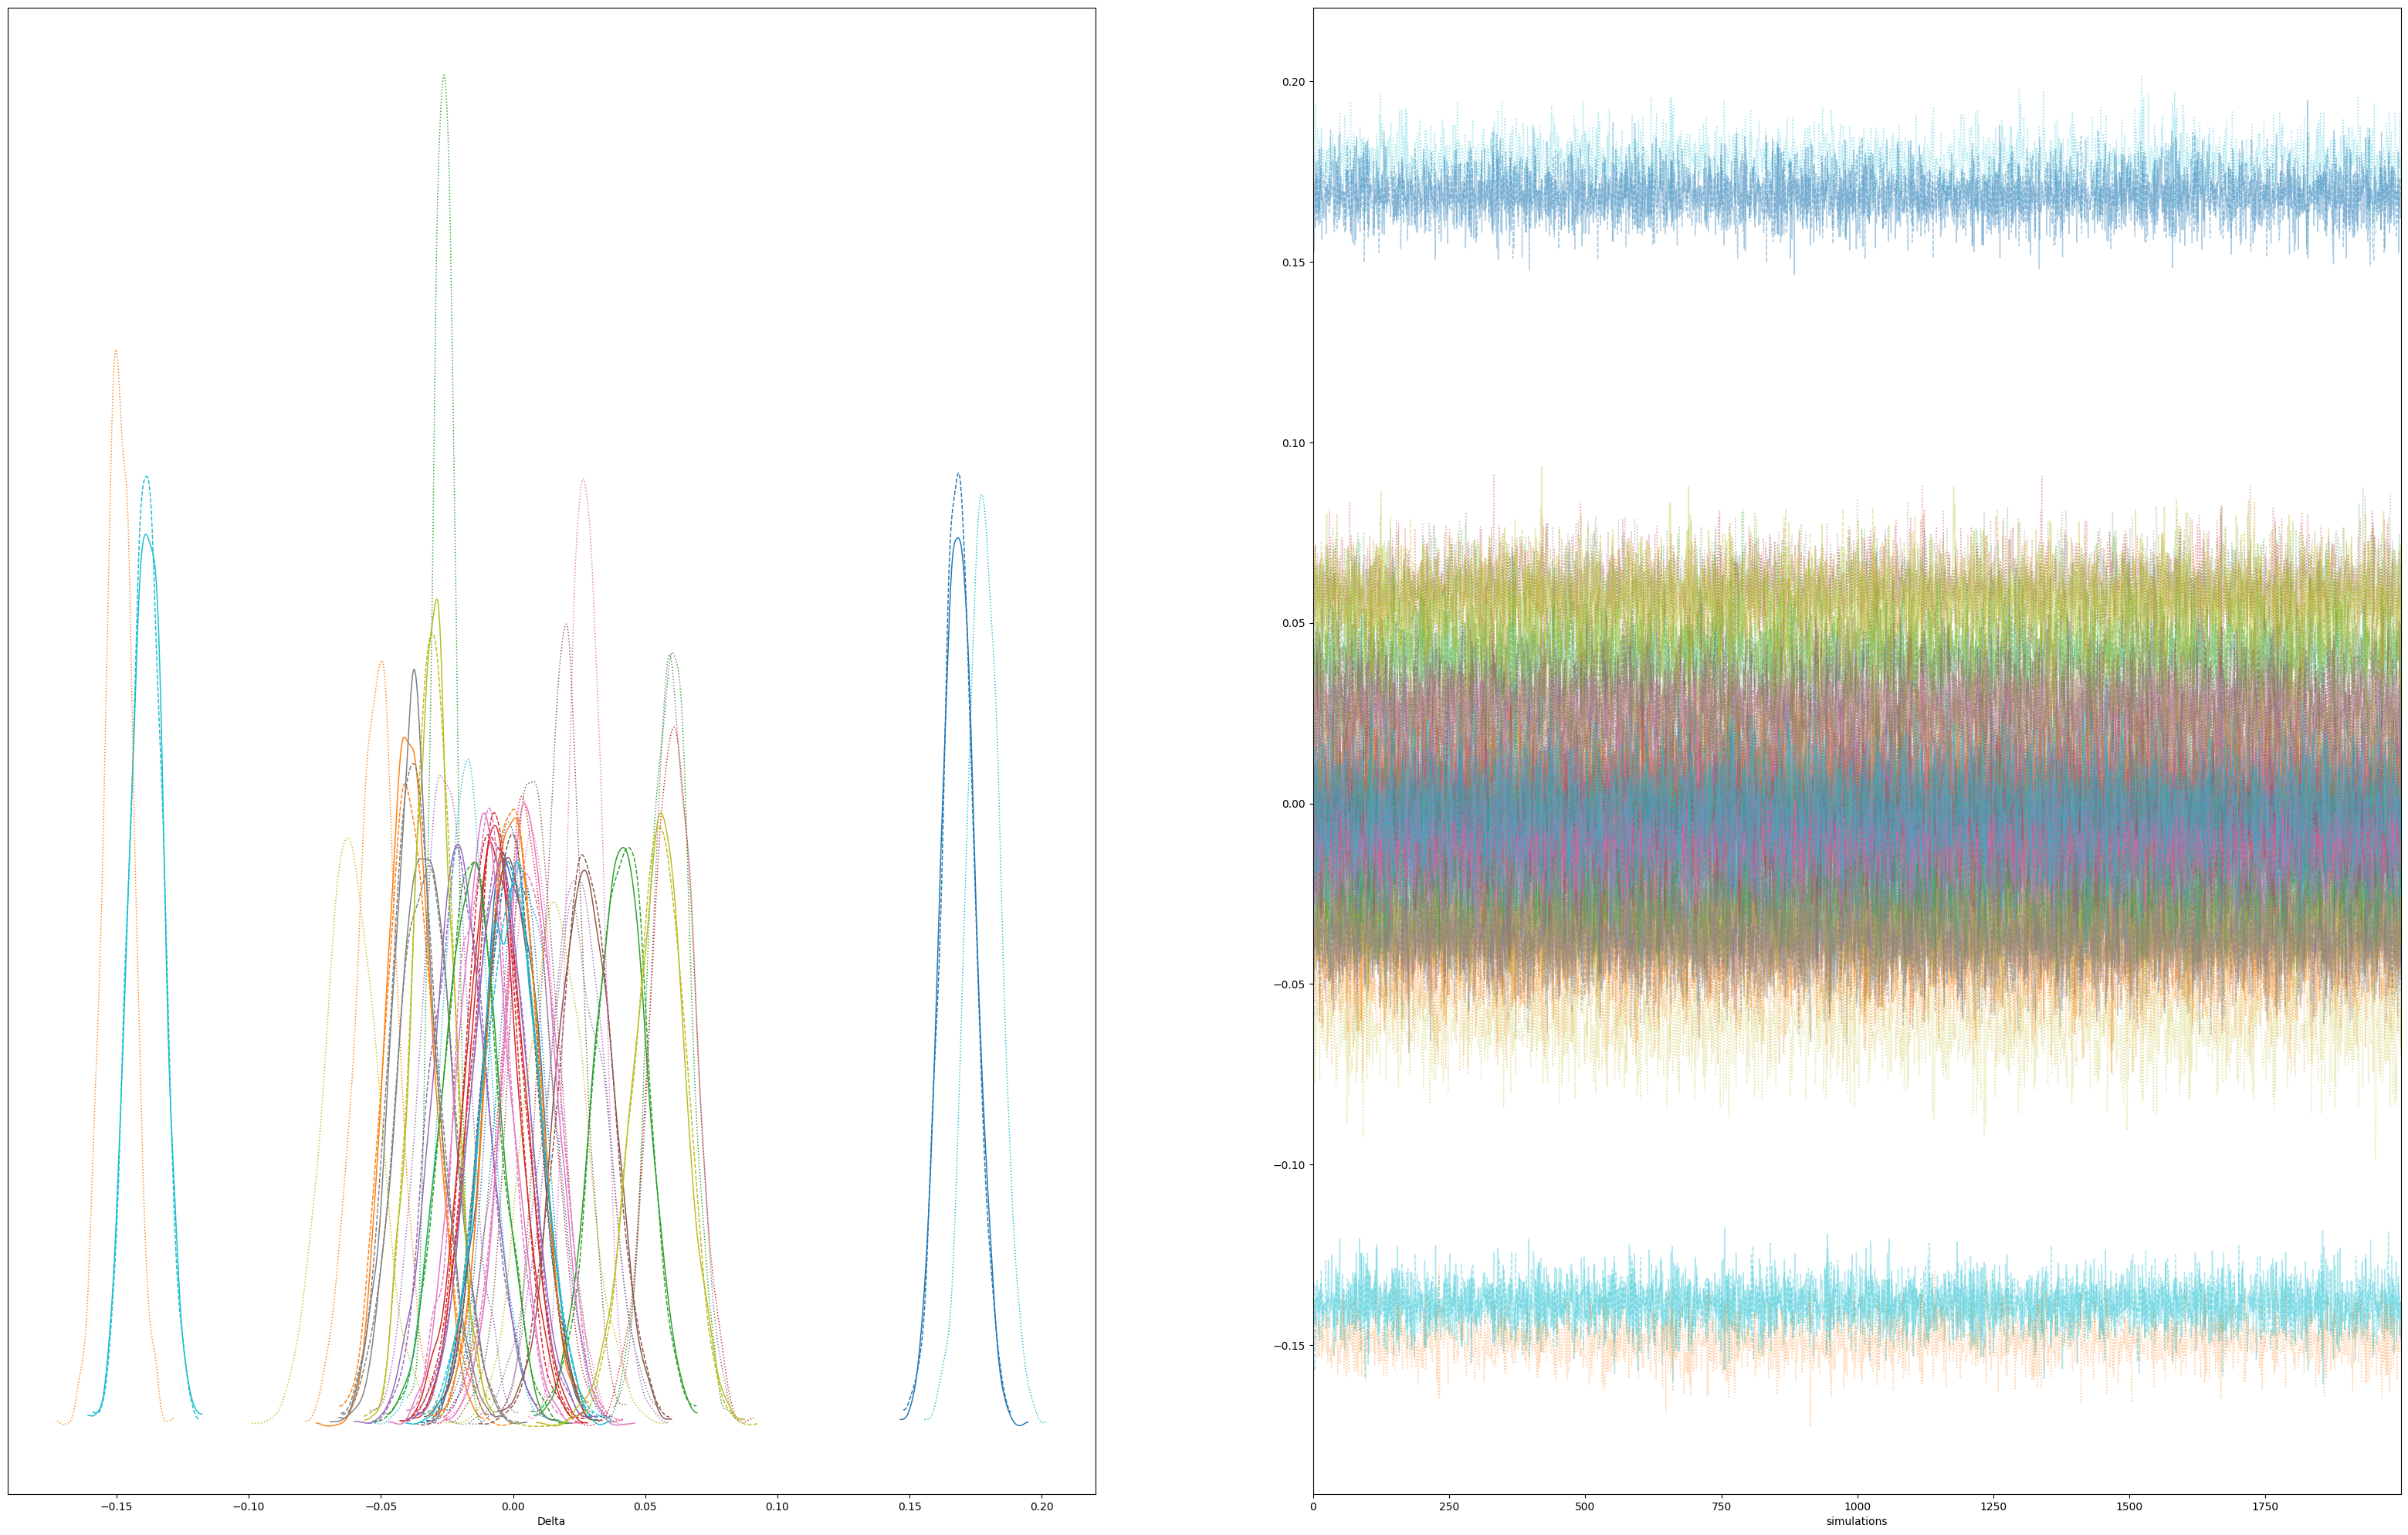

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(40, 25),squeeze=False)
p1=az.plot_trace(nuts_inference, axes=axes[:,:])
for ax in axes.ravel():
    ax.set_title("")
axes[0, 1].set_xlabel("simulations")
axes[0, 0].set_xlabel("Delta")

In [121]:
import pickle
with open('/mnt/pml/samples_MCMC.pkl', 'wb') as file:
    pickle.dump(samples, file)

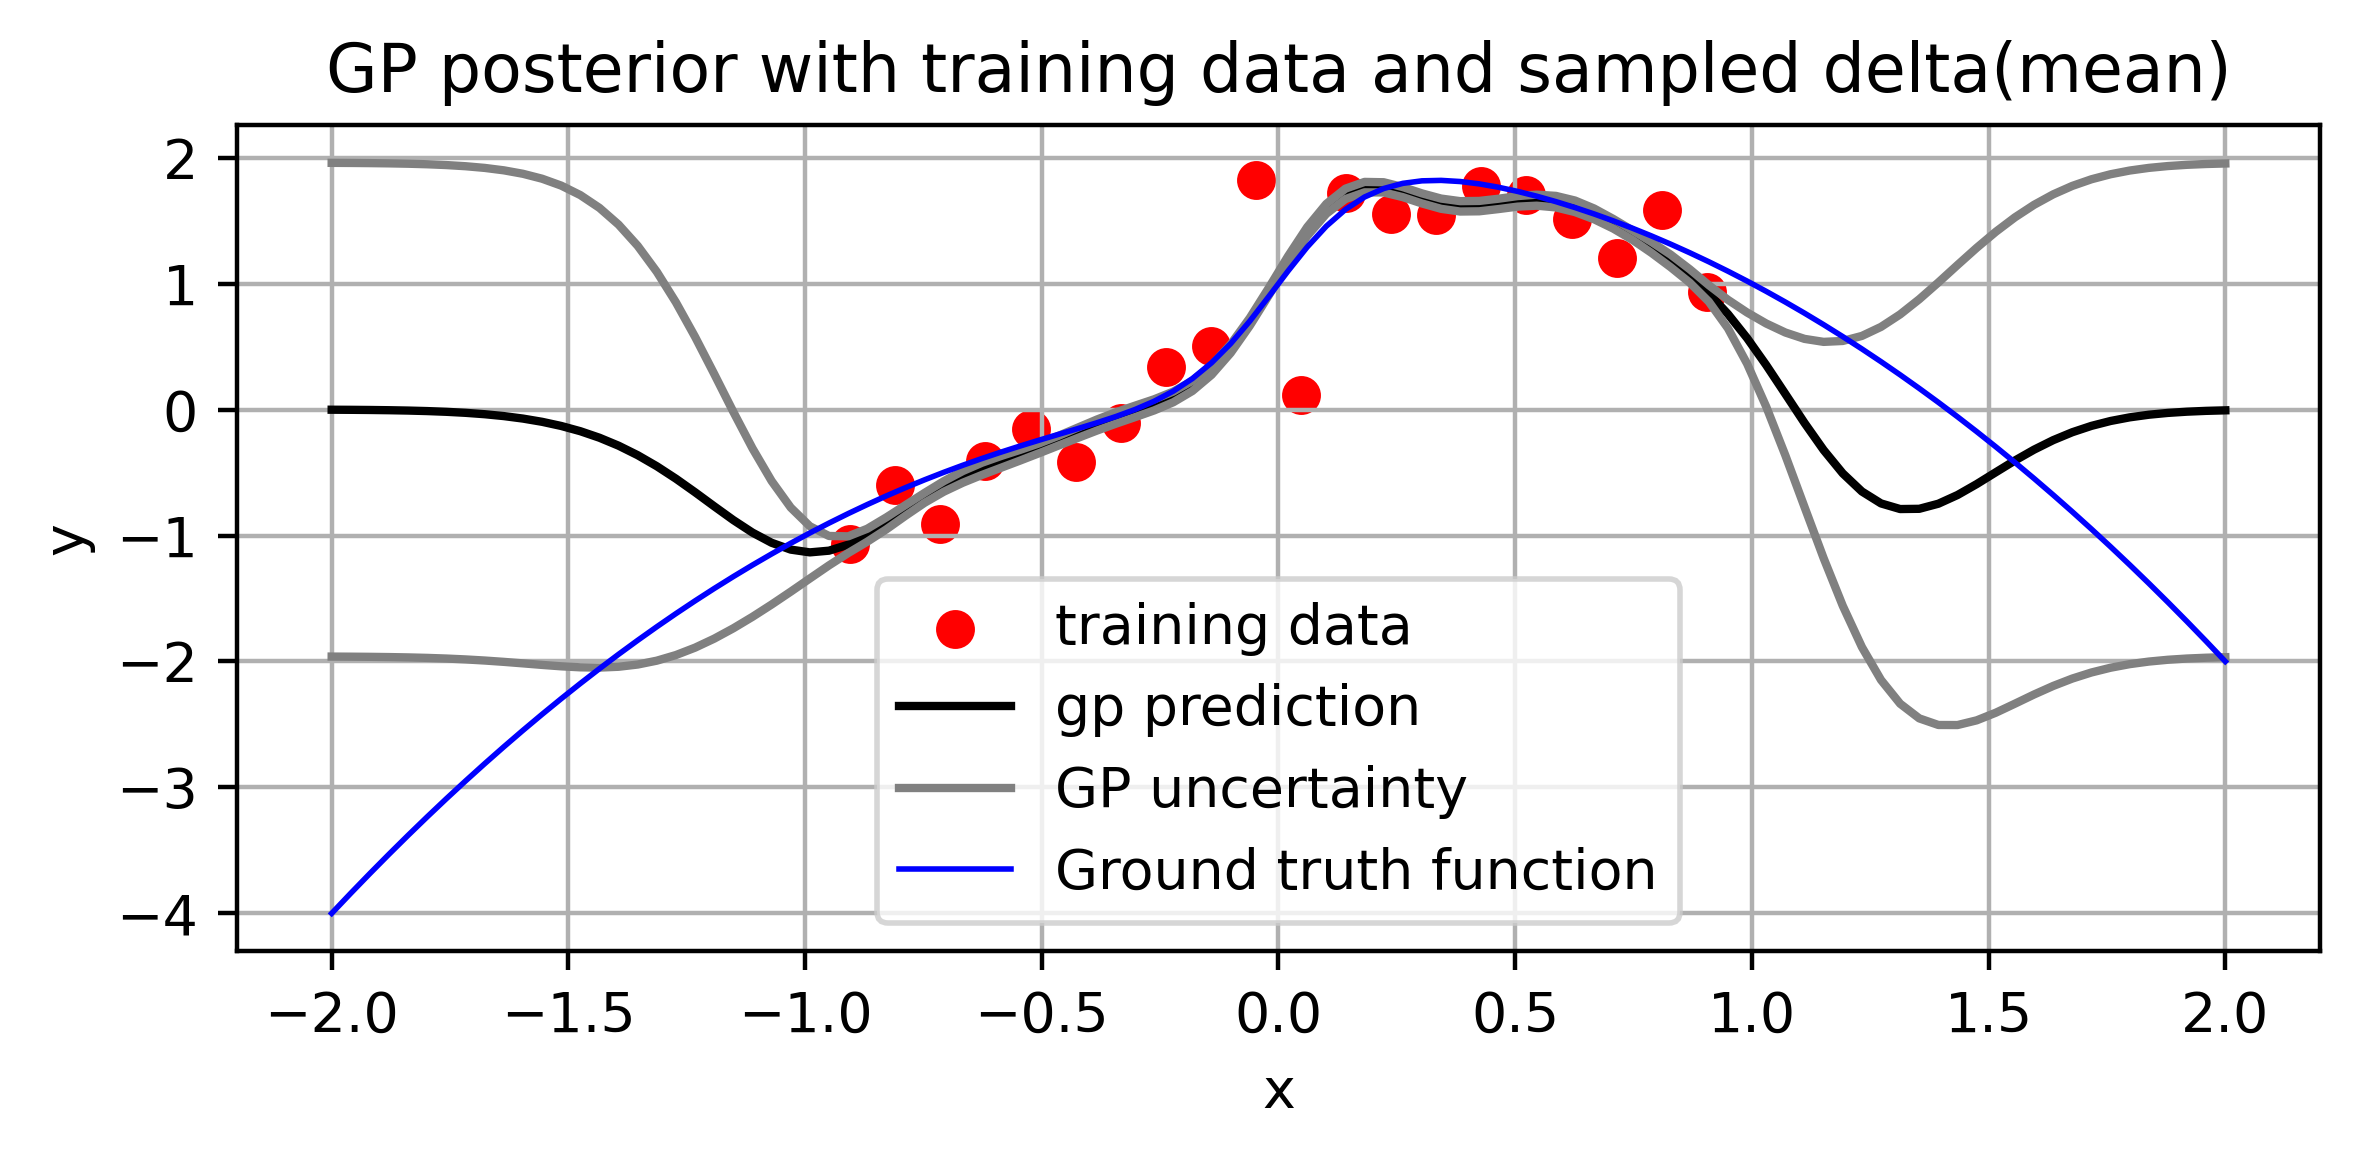

In [122]:
X_grid = np.linspace(-2, 2, 100)
mu_list = []
var_list = []
for sample in samples[0]:
    mu, Sigma = conditional(X_grid, X_noisy, y, noise_var, eta, K, sample.numpy())
    var=np.diag(Sigma)
    mu_list.append(mu)
    var_list.append(var)
mu=np.mean(np.array(mu_list),axis=0)
var=np.mean(np.array(var_list),axis=0)
# mu, Sigma = conditional(X_grid, X_noisy, y, noise_var, eta, K, delta)
## X_grid: the grid where prediction makes, and thus in this case the delta on the prediction should be 0
plt.figure(dpi=400,figsize=(6,3))

plt.scatter(X_noisy, y, color='red', label='training data')
plt.plot(X_grid, mu, color='black', label='gp prediction')
plt.plot(X_grid, mu + 1.96*var**0.5, color='grey', label='GP uncertainty')
plt.plot(X_grid, mu - 1.96*var**0.5, color='grey')
plt.plot(X_grid, f_ground_truth(X_grid), color="blue", lw=1, label="Ground truth function")
plt.title('GP posterior with training data and sampled delta(mean)')
plt.xlabel("x")
plt.ylabel("y")
plt.axis('on')
plt.grid(True)
plt.legend()
plt.tight_layout()

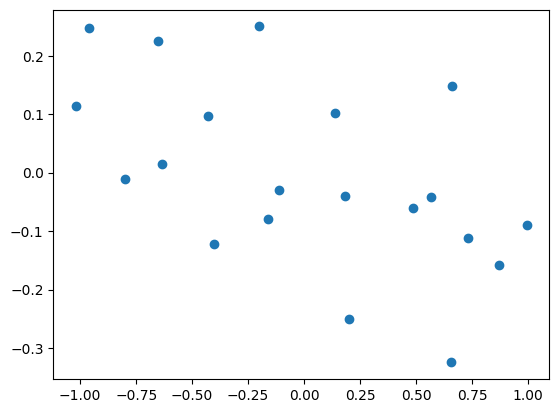

In [123]:
#Plot delta tendency:
plt.scatter(X_clean, delta)

coef:  [-0.13706108]


Text(0.5, 1.0, 'data-delta regression')

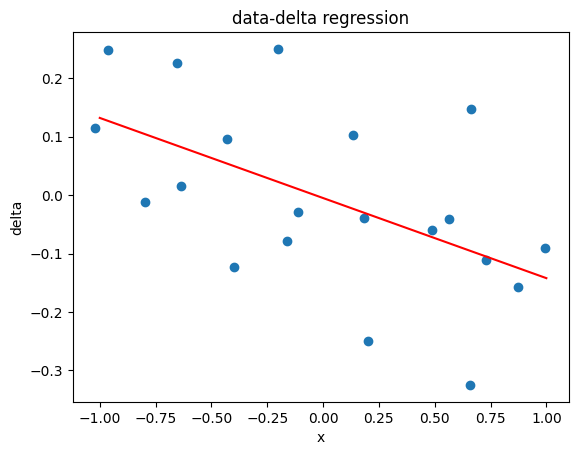

In [132]:
import numpy as np
from sklearn.linear_model import LinearRegression
x_range = np.linspace(-1,1, 100)
reg = LinearRegression().fit(X_clean.reshape(-1,1), delta)
print("coef: ", reg.coef_)
plt.scatter(X_clean, delta)
plt.plot(x_range, reg.predict(x_range.reshape(-1,1)), color="red")
plt.xlabel("x")
plt.ylabel("delta")
plt.title("data-delta regression")

In [125]:
# delta_i = N(-0.13*x_clean, var_x) 

(array([1.73972694, 0.        , 1.73972694, 0.        , 0.        ,
        1.73972694, 0.        , 3.47945388, 3.47945388, 5.21918082,
        3.47945388, 1.73972694, 0.        , 0.        , 3.47945388,
        1.73972694, 1.73972694, 0.        , 0.        , 5.21918082]),
 array([-0.32480285, -0.29606271, -0.26732256, -0.23858242, -0.20984228,
        -0.18110214, -0.15236199, -0.12362185, -0.09488171, -0.06614157,
        -0.03740142, -0.00866128,  0.02007886,  0.048819  ,  0.07755915,
         0.10629929,  0.13503943,  0.16377957,  0.19251972,  0.22125986,
         0.25      ]),
 <BarContainer object of 20 artists>)

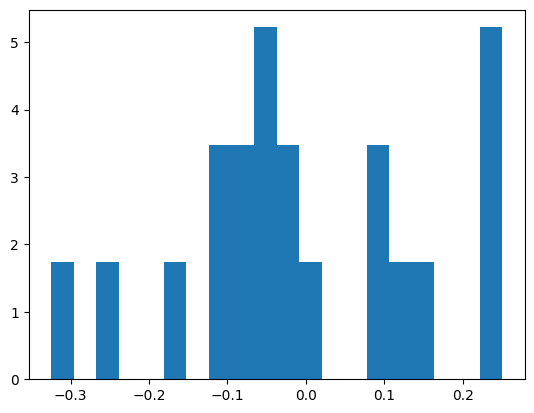

In [126]:
plt.hist(delta.flatten(), bins=20, density=True)